In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load the dataset
df = pd.read_csv('/Users/daniyalrosli/booklens/Books.csv')



/var/folders/22/c035bpr92994vmxx8mhst1mw0000gn/T/ipykernel_33070/3506037573.py:5: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/Users/daniyalrosli/booklens/Books.csv')


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 271357 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ISBN                 271357 non-null  object 
 1   Book-Title           271357 non-null  object 
 2   Book-Author          271355 non-null  object 
 3   Year-Of-Publication  271357 non-null  float64
 4   Publisher            271355 non-null  object 
 5   Image-URL-S          271357 non-null  object 
 6   Image-URL-M          271357 non-null  object 
 7   Image-URL-L          271357 non-null  object 
dtypes: float64(1), object(7)
memory usage: 18.6+ MB


In [5]:
# Handle missing values
df.dropna(inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Convert data types if necessary
df['Year-Of-Publication'] = df['Year-Of-Publication'].astype(int)

# Define numerical columns
numerical_cols = ['Year-Of-Publication']

# Standardize numerical columns
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

df.isnull().sum()
df.isnull().sum().sum()

# Display the cleaned dataframe
df.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,0.163723,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,0.159847,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,0.121086,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,0.152095,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,0.152095,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [3]:
# Handle missing values
df.dropna(inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)


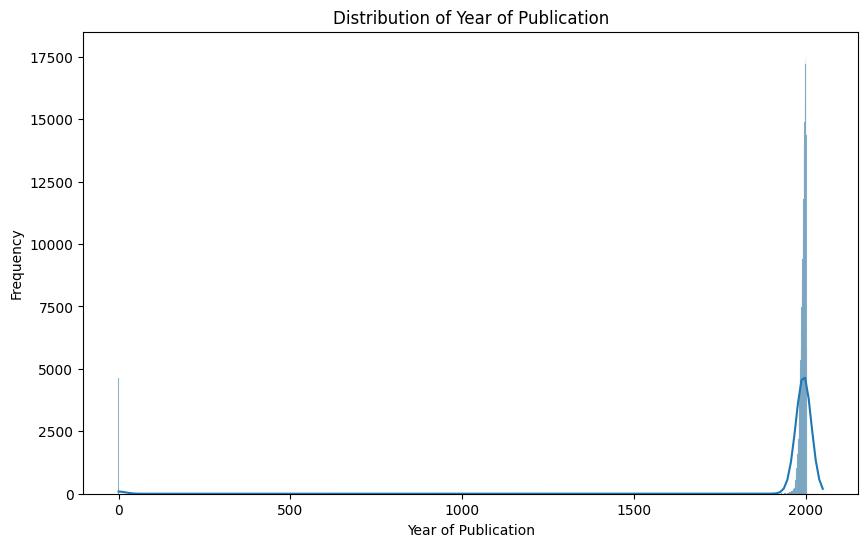

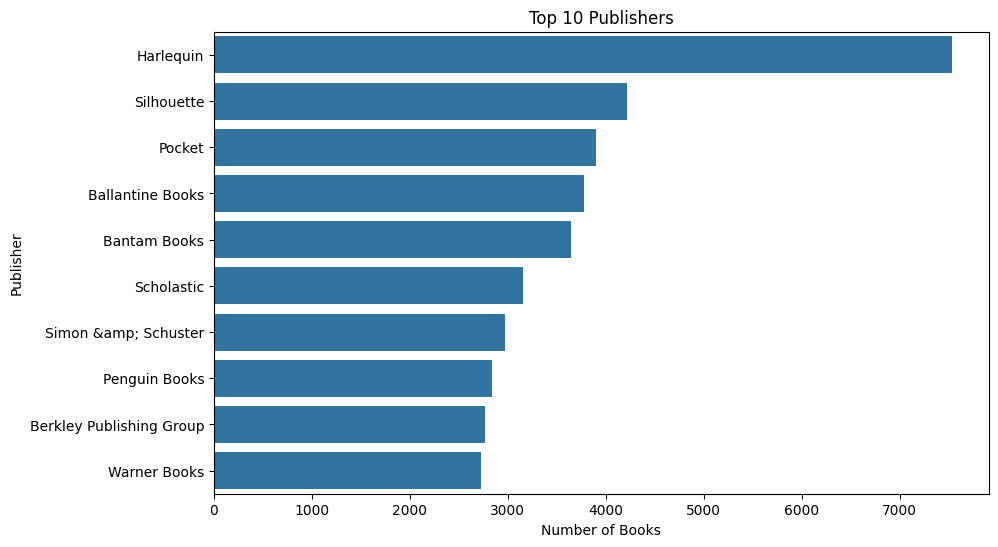

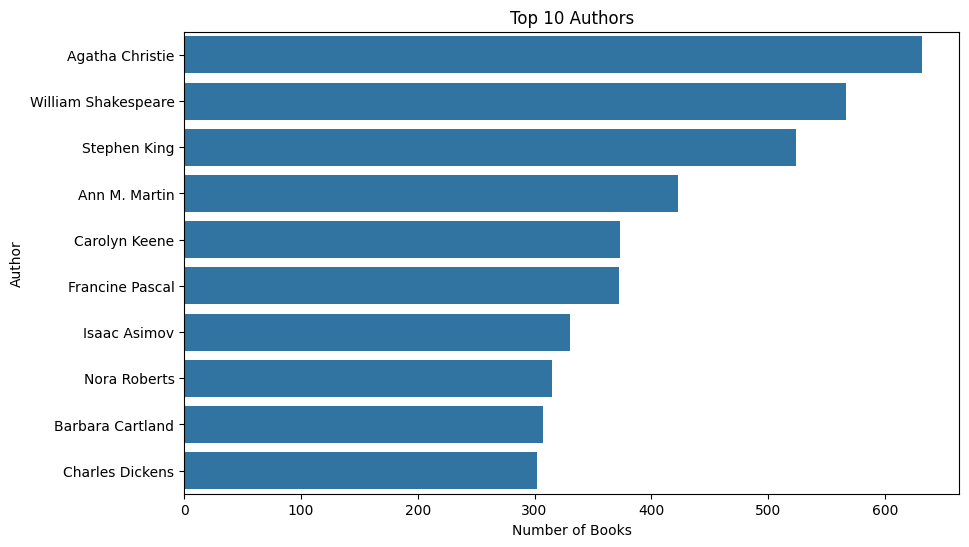

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the distribution of the 'Year-Of-Publication' column
plt.figure(figsize=(10, 6))
sns.histplot(df['Year-Of-Publication'], bins=30, kde=True)
plt.title('Distribution of Year of Publication')
plt.xlabel('Year of Publication')
plt.ylabel('Frequency')
plt.show()

# Plot the top 10 publishers
top_publishers = df['Publisher'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_publishers.values, y=top_publishers.index)
plt.title('Top 10 Publishers')
plt.xlabel('Number of Books')
plt.ylabel('Publisher')
plt.show()

# Plot the top 10 authors
top_authors = df['Book-Author'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_authors.values, y=top_authors.index)
plt.title('Top 10 Authors')
plt.xlabel('Number of Books')
plt.ylabel('Author')
plt.show()




In [9]:
#feature engineering

# Feature Engineering

# Extract the first letter of the book title to create a new feature
df['Title_First_Letter'] = df['Book-Title'].str[0]

# Create a feature for the length of the book title
df['Title_Length'] = df['Book-Title'].apply(len)

# Create a feature for the number of words in the book title
df['Title_Word_Count'] = df['Book-Title'].apply(lambda x: len(x.split()))

# Create a feature for the number of books published by the same author
df['Author_Book_Count'] = df['Book-Author'].map(df['Book-Author'].value_counts())

# Create a feature for the number of books published by the same publisher
df['Publisher_Book_Count'] = df['Publisher'].map(df['Publisher'].value_counts())

# Display the dataframe with new features
df.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L,Title_First_Letter,Title_Length,Title_Word_Count,Author_Book_Count,Publisher_Book_Count
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,C,19,2,2,1502
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,C,12,2,2,15
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,D,20,3,3,8
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,F,98,19,2,263
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,T,22,4,1,739


In [10]:
from sklearn.model_selection import train_test_split

# Define the features and target variable
X = df.drop(columns=['Book-Title', 'Book-Author', 'Publisher', 'Image-URL-S', 'Image-URL-M', 'Image-URL-L'])
y = df['Book-Title']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shapes of the resulting datasets
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (217082, 7)
X_test shape: (54271, 7)
y_train shape: (217082,)
y_test shape: (54271,)


In [17]:
# Feature Engineering

# Extract the first letter of the book title to create a new feature
df['Title_First_Letter'] = df['Book-Title'].str[0]

# Create a feature for the length of the book title
df['Title_Length'] = df['Book-Title'].apply(len)

# Create a feature for the number of words in the book title
df['Title_Word_Count'] = df['Book-Title'].apply(lambda x: len(x.split()))

# Create a feature for the number of books published by the same author
df['Author_Book_Count'] = df['Book-Author'].map(df['Book-Author'].value_counts())

# Create a feature for the number of books published by the same publisher
df['Publisher_Book_Count'] = df['Publisher'].map(df['Publisher'].value_counts())

# Create a feature for the average length of book titles by the same author
df['Author_Avg_Title_Length'] = df.groupby('Book-Author')['Title_Length'].transform('mean')

# Create a feature for the average number of words in book titles by the same author
df['Author_Avg_Title_Word_Count'] = df.groupby('Book-Author')['Title_Word_Count'].transform('mean')

# Create a feature for the average length of book titles by the same publisher
df['Publisher_Avg_Title_Length'] = df.groupby('Publisher')['Title_Length'].transform('mean')

# Create a feature for the average number of words in book titles by the same publisher
df['Publisher_Avg_Title_Word_Count'] = df.groupby('Publisher')['Title_Word_Count'].transform('mean')

# Display the dataframe with new features
df.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L,Title_First_Letter,Title_Length,Title_Word_Count,Author_Book_Count,Publisher_Book_Count,Author_Avg_Title_Length,Author_Avg_Title_Word_Count,Publisher_Avg_Title_Length,Publisher_Avg_Title_Word_Count
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,C,19,2,2,1502,19.0,2.0,49.386152,7.310253
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,C,12,2,2,15,17.0,2.5,35.733333,6.200000
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,D,20,3,3,8,24.0,4.0,59.750000,9.500000
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,F,98,19,2,263,71.0,14.0,27.939163,4.878327
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,T,22,4,1,739,22.0,4.0,49.568336,7.562923
